In [12]:
import requests
from IPython.display import Image, display
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.patheffects as pe
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
import matplotlib.font_manager as fm
from PIL import Image as PILImage
import numpy as np
from io import BytesIO
import os
import time


In [16]:
# Point to your downloaded font file
font_path = '../assets/fonts/Bebas_Neue/BebasNeue-Regular.ttf'
fm.fontManager.addfont(font_path)

# Set it globally for the whole figure
plt.rcParams['font.family'] = 'Bebas Neue'

In [ ]:

# GROUP_ID looks lake "-203400-203401-..." 
# extract player IDs from your a lineup and test a headshot

adv_df = pd.read_csv('../data/raw/storm_lineups_advanced.csv')

# Find your best lineup by net rating with 100+ possessions
best_lineups = adv_df[adv_df['POSS'] >= 100].nlargest(5, 'NET_RATING')[['GROUP_NAME', 'GROUP_ID', 'NET_RATING', 'POSS', 'SEASON']]
print(best_lineups)

# Extract player IDs from GROUP_ID of the top lineup
top_lineup = best_lineups.iloc[0]
player_ids = [pid for pid in top_lineup['GROUP_ID'].split('-') if pid.strip()]
print(f"\nPlayer IDs: {player_ids}")

# Test headshot URL for first player
test_id = player_ids[0]
url = f"https://ak-static.cms.nba.com/wp-content/uploads/headshots/wnba/latest/260x190/{test_id}.png"
print(f"\nTesting URL: {url}")

response = requests.get(url)
print(f"Status code: {response.status_code}")
if response.status_code == 200:
    display(Image(url=url))
else:
    print("Headshot not found at this URL")

                                             GROUP_NAME  \
1363  B. Lennox - L. Jackson - S. Bird - I. Castro M...   
2001  S. Abrosimova - L. Jackson - S. Bird - S. Cash...   
1349  B. Lennox - J. Burse - L. Jackson - S. Bird - ...   
1347  T. Johnson - B. Lennox - L. Jackson - S. Bird ...   
1364  W. Palmer - B. Lennox - L. Jackson - S. Bird -...   

                                  GROUP_ID  NET_RATING  POSS  SEASON  
1363  -100484-100682-100720-100796-100942-        61.0   147    2007  
2001  -100658-100682-100720-100721-201067-        34.2   109    2010  
1349  -100484-100660-100682-100720-200681-        27.9   182    2006  
1347  -100233-100484-100682-100720-200681-        25.5   118    2006  
1364  -100046-100484-100682-100720-100796-        25.0   113    2007  

Player IDs: ['100484', '100682', '100720', '100796', '100942']

Testing URL: https://ak-static.cms.nba.com/wp-content/uploads/headshots/wnba/latest/260x190/100484.png
Status code: 403
Headshot not found at this URL


In [2]:
headers = {
    'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120.0.0.0 Safari/537.36',
    'Referer': 'https://www.wnba.com/'
}

# Also try a few different URL patterns
test_id = player_ids[0]
urls = [
    f"https://ak-static.cms.nba.com/wp-content/uploads/headshots/wnba/latest/260x190/{test_id}.png",
    f"https://cdn.nba.com/headshots/wnba/latest/260x190/{test_id}.png",
    f"https://cdn.wnba.com/headshots/wnba/latest/260x190/{test_id}.png",
]

for url in urls:
    response = requests.get(url, headers=headers)
    print(f"{url}")
    print(f"  Status: {response.status_code}\n")

https://ak-static.cms.nba.com/wp-content/uploads/headshots/wnba/latest/260x190/100484.png
  Status: 403

https://cdn.nba.com/headshots/wnba/latest/260x190/100484.png
  Status: 403

https://cdn.wnba.com/headshots/wnba/latest/260x190/100484.png
  Status: 200



In [3]:
from IPython.display import Image, display

url = f"https://cdn.wnba.com/headshots/wnba/latest/260x190/{test_id}.png"
response = requests.get(url, headers=headers)

if response.status_code == 200:
    display(Image(url=url))
else:
    print(f"Failed: {response.status_code}")


# If this returns a headshot we're good to build the full graphic. The URL pattern for every player will be:

# https://cdn.wnba.com/headshots/wnba/latest/260x190/{player_id}.png

In [38]:
# Check what season the top lineup is from
print(best_lineups[['GROUP_NAME', 'GROUP_ID', 'NET_RATING', 'POSS', 'SEASON']].head())

# Also test a known current Storm player
# Ezi Magbegor, Jewell Loyd, others from recent seasons
# Let's find player IDs from 2025 specifically
recent_lineups = adv_df[adv_df['SEASON'] == 2025].nlargest(3, 'POSS')[['GROUP_NAME', 'GROUP_ID']]
print("\n2025 top lineups:")
print(recent_lineups)

# Extract and test IDs from a 2024 lineup
recent_ids = [pid for pid in recent_lineups.iloc[0]['GROUP_ID'].split('-') if pid.strip()]
print(f"\n2025 player IDs: {recent_ids}")

for pid in recent_ids:
    url = f"https://cdn.wnba.com/headshots/wnba/latest/260x190/{pid}.png"
    response = requests.get(url, headers=headers)
    print(f"{pid}: {response.status_code}")
    if response.status_code == 200:
        display(Image(url=url))

                                             GROUP_NAME  \
1363  B. Lennox - L. Jackson - S. Bird - I. Castro M...   
2001  S. Abrosimova - L. Jackson - S. Bird - S. Cash...   
1349  B. Lennox - J. Burse - L. Jackson - S. Bird - ...   
1347  T. Johnson - B. Lennox - L. Jackson - S. Bird ...   
1364  W. Palmer - B. Lennox - L. Jackson - S. Bird -...   

                                  GROUP_ID  NET_RATING  POSS  SEASON  
1363  -100484-100682-100720-100796-100942-        61.0   147    2007  
2001  -100658-100682-100720-100721-201067-        34.2   109    2010  
1349  -100484-100660-100682-100720-200681-        27.9   182    2006  
1347  -100233-100484-100682-100720-200681-        25.5   118    2006  
1364  -100046-100484-100682-100720-100796-        25.0   113    2007  

2025 top lineups:
                                             GROUP_NAME  \
4100  N. Ogwumike - S. Diggins - E. Wheeler - G. Wil...   
4101  N. Ogwumike - S. Diggins - B. Sykes - G. Willi...   
4102  A. Clark - N. Ogw

203400: 200


204365: 200


1628931: 200


1629496: 200


Possession distribution:
count    4256.000000
mean       16.770677
std        53.892730
min         0.000000
25%         3.000000
50%         6.000000
75%        13.000000
max      1094.000000
Name: POSS, dtype: float64

Percentiles:
  50th percentile: 6 poss
  75th percentile: 13 poss
  85th percentile: 23 poss
  90th percentile: 31 poss
  95th percentile: 53 poss
  99th percentile: 209 poss

Lineup counts at different thresholds:
  50+ poss: 234 lineups
  100+ poss: 93 lineups
  150+ poss: 58 lineups
  200+ poss: 44 lineups
  250+ poss: 36 lineups
  300+ poss: 27 lineups
  400+ poss: 17 lineups
  500+ poss: 13 lineups


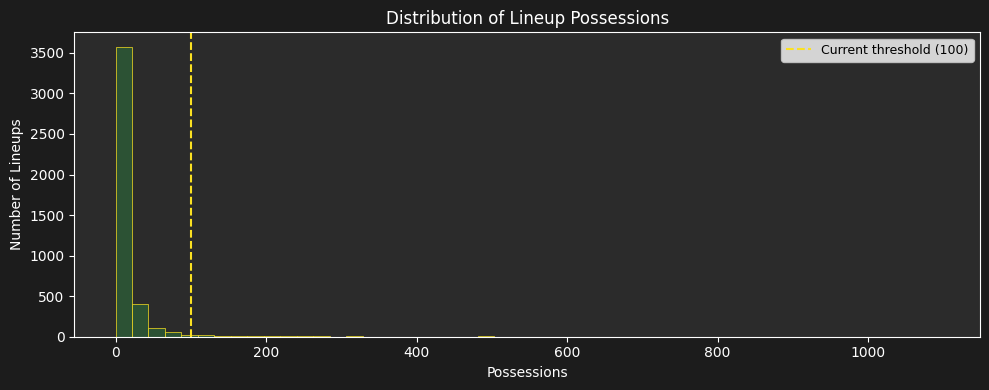

In [39]:
# where should the cutoff in number of possessions be for filtering?

poss_data = adv_df['POSS'].sort_values(ascending=False)

# Summary statistics
print("Possession distribution:")
print(poss_data.describe())
print(f"\nPercentiles:")
for p in [50, 75, 85, 90, 95, 99]:
    print(f"  {p}th percentile: {poss_data.quantile(p/100):.0f} poss")

# How many lineups at different thresholds
print(f"\nLineup counts at different thresholds:")
for threshold in [50, 100, 150, 200, 250, 300, 400, 500]:
    count = len(adv_df[adv_df['POSS'] >= threshold])
    print(f"  {threshold}+ poss: {count} lineups")

# Visualize the distribution
fig, ax = plt.subplots(figsize=(10, 4))
fig.patch.set_facecolor('#1c1c1c')
ax.set_facecolor('#2b2b2b')
ax.hist(poss_data, bins=50, color='#2C5234', edgecolor='#FBE122', linewidth=0.5)
ax.axvline(100, color='#FBE122', linestyle='--', label='Current threshold (100)')
ax.set_xlabel('Possessions', color='white')
ax.set_ylabel('Number of Lineups', color='white')
ax.set_title('Distribution of Lineup Possessions', color='white')
ax.tick_params(colors='white')
ax.legend(fontsize=9)
for spine in ax.spines.values():
    spine.set_edgecolor('white')
plt.tight_layout()
plt.show()

In [6]:
headers = {
    'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36',
    'Referer': 'https://www.wnba.com/'
}

# ---- Step 1: Find top 5 lineups in franchise history ----
top5 = (adv_df[adv_df['POSS'] >= 200]
        .nlargest(5, 'NET_RATING')
        [['SEASON', 'GROUP_NAME', 'GROUP_ID', 'NET_RATING', 'OFF_RATING', 'DEF_RATING', 'POSS']]
        .reset_index(drop=True))

print(top5)

   SEASON                                         GROUP_NAME  \
0    2020  S. Bird - A. Clark - N. Howard - J. Loyd - B. ...   
1    2022  S. Bird - T. Charles - J. Loyd - B. Stewart - ...   
2    2018  S. Bird - A. Clark - N. Howard - J. Loyd - B. ...   
3    2021  S. Bird - S. Talbot - J. Loyd - B. Stewart - M...   
4    2010  L. Jackson - S. Bird - S. Cash - T. Wright - C...   

                                 GROUP_ID  NET_RATING  OFF_RATING  DEF_RATING  \
0   -100720-202252-203827-204319-1627668-        23.4       111.9        88.4   
1  -100720-202250-204319-1627668-1628931-        20.9       114.7        93.9   
2   -100720-202252-203827-204319-1627668-        20.6       117.6        97.1   
3  -100720-203855-204319-1627668-1628920-        19.3       106.5        87.1   
4    -100682-100720-100721-101030-201067-        17.0       106.6        89.6   

   POSS  
0   345  
1   455  
2  1094  
3   278  
4   834  


In [108]:
# remove the background of the manually downloaded images for the players who will not have headshots
from rembg import remove
from PIL import Image

def remove_background(input_path, output_path):
    with open(input_path, 'rb') as f:
        input_data = f.read()
    output_data = remove(input_data)
    with open(output_path, 'wb') as f:
        f.write(output_data)
    print(f"Saved: {output_path}")

# Run on specific headshots 
remove_background('../assets/headshots/100682.jpg', '../assets/headshots/100682.png')
remove_background('../assets/headshots/100721.jpg', '../assets/headshots/100721.png')

Saved: ../assets/headshots/100682.png
Saved: ../assets/headshots/100721.png


In [ ]:
# resize the manually downloaded images
def resize_preserve_aspect(input_path, output_path, target_size=(260, 190)):
    img = Image.open(input_path).convert('RGBA')
    img.thumbnail(target_size, Image.LANCZOS)  # preserves aspect ratio
    
    # Paste onto a transparent canvas of exact target size to center it
    canvas = Image.new('RGBA', target_size, (0, 0, 0, 0))
    offset_x = (target_size[0] - img.width) // 2
    offset_y = (target_size[1] - img.height) // 2
    canvas.paste(img, (offset_x, offset_y))
    canvas.save(output_path)
    print(f"Saved: {output_path} — final size: {canvas.size}")

resize_preserve_aspect('../assets/headshots/100682.png', '../assets/headshots/100682.png')
resize_preserve_aspect('../assets/headshots/100721.png', '../assets/headshots/100721.png')

Saved: ../assets/headshots/100682.png — final size: (260, 190)
Saved: ../assets/headshots/100721.png — final size: (260, 190)


Fetching positions...
  S. Bird: Guard
  A. Clark: Forward
  N. Howard: Forward
  J. Loyd: Guard
  B. Stewart: Forward
  T. Charles: Center
  G. Williams: Forward
  S. Talbot: Forward
  M. Russell: Center
  L. Jackson: Forward-Center
  S. Cash: Forward
  T. Wright: Guard
  C. Little: Forward


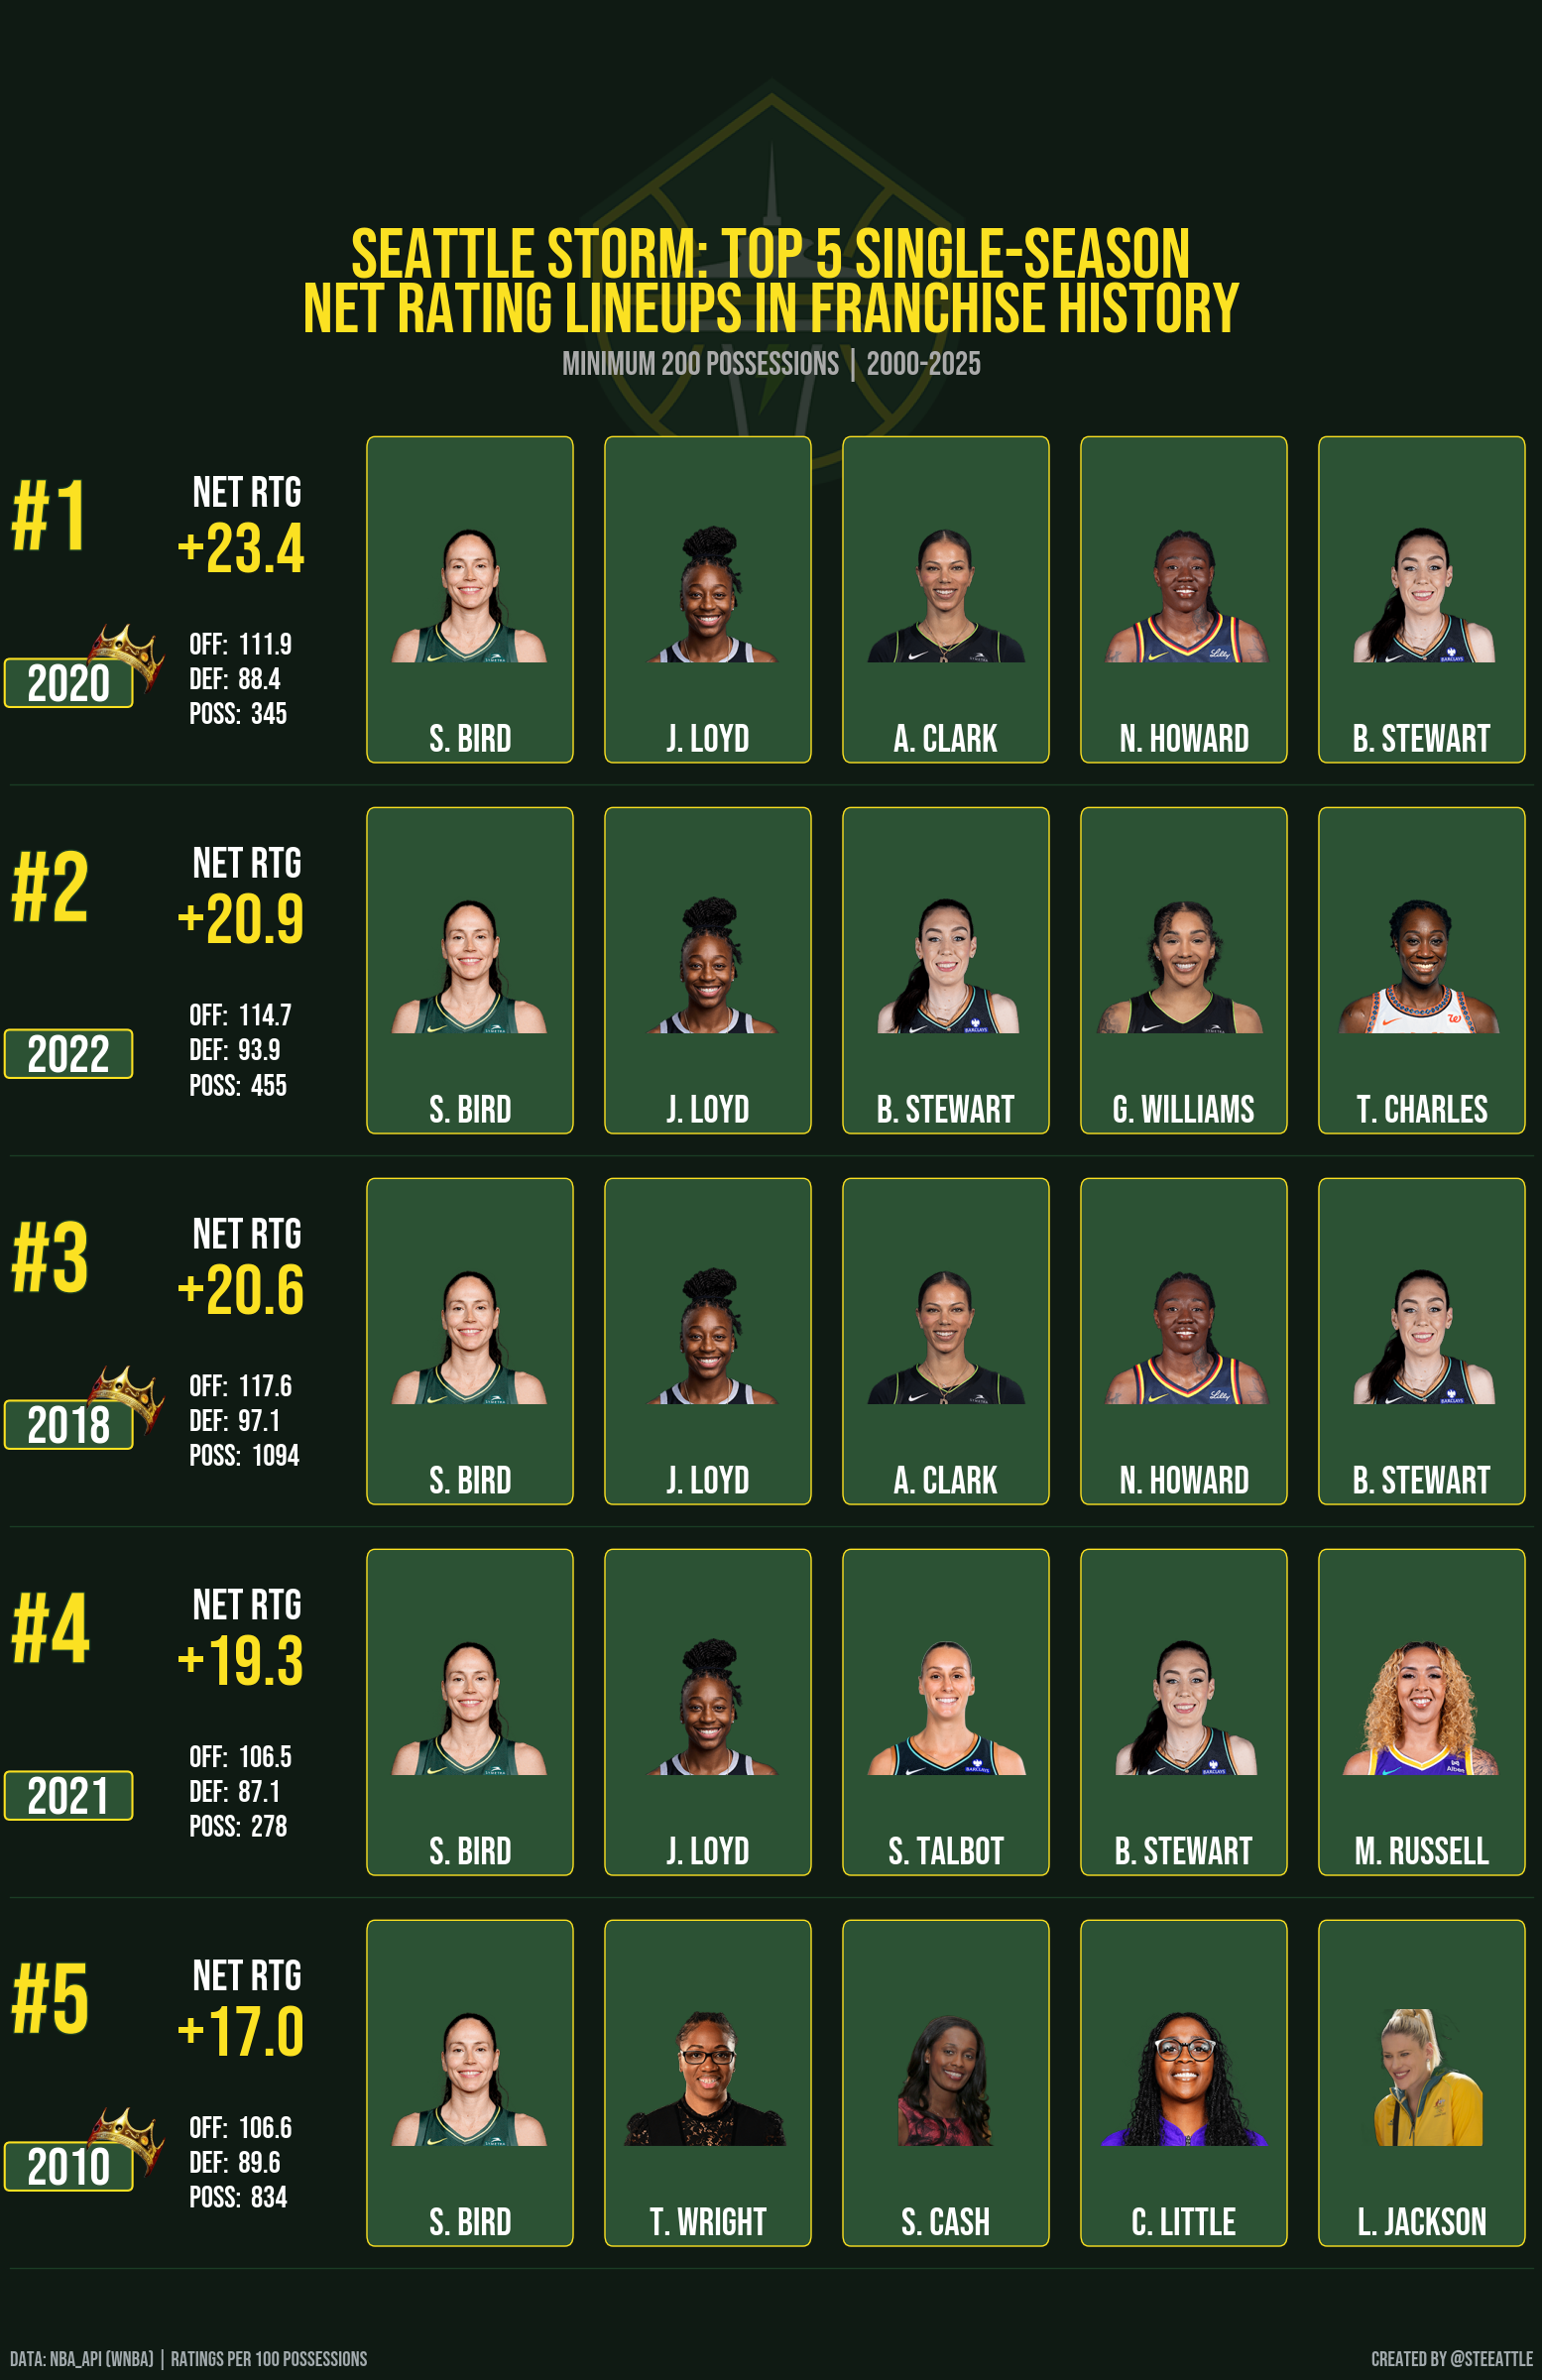

Saved to ../outputs/storm_top5_lineups.png


In [24]:
# ---- Step 2: Headshot fetcher ----
HEADSHOT_DIR = '../assets/headshots/'

def get_headshot(player_id, player_name):
    # Check local first
    local_path = None
    for ext in ['png', 'jpg', 'jpeg', 'webp']:
        candidate = os.path.join(HEADSHOT_DIR, f'{player_id}.{ext}')
        if os.path.exists(candidate):
            local_path = candidate
            break

    if local_path:
        img = PILImage.open(local_path).convert('RGBA')
        return np.array(img), False
    
    # Fall back to CDN
    url = f"https://cdn.wnba.com/headshots/wnba/latest/260x190/{player_id}.png"
    try:
        response = requests.get(url, headers=headers, timeout=5)
        if response.status_code == 200:
            if len(response.content) < 5000:
                return None, True
            img = PILImage.open(BytesIO(response.content)).convert('RGBA')
            return np.array(img), False
    except:
        pass
    return None, True

# ---- Step 3: Parse player names and IDs ----
def parse_lineup(row):
    names = [n.strip() for n in row['GROUP_NAME'].split(' - ')]
    ids = [pid for pid in row['GROUP_ID'].split('-') if pid.strip()]
    return list(zip(names, ids))

# get positions so the cards can appear in order
from nba_api.stats.endpoints import commonplayerinfo

def get_player_position(player_id):
    try:
        info = commonplayerinfo.CommonPlayerInfo(
            player_id=player_id,
            league_id_nullable='10'
        ).get_data_frames()[0]
        position = info['POSITION'].iloc[0]
        time.sleep(1)
        return position
    except Exception as e:
        print(f"Failed {player_id}: {e}")
        return None

# Get all unique players across top5
all_players = []
for _, row in top5.iterrows():
    all_players.extend(parse_lineup(row))

unique_players = list({pid: name for name, pid in all_players}.items())

print("Fetching positions...")
position_map = {}
for pid, name in unique_players:
    pos = get_player_position(pid)
    print(f"  {name}: {pos}")
    position_map[pid] = pos

POSITION_ORDER = {
    'Guard': 1,
    'Guard-Forward': 2,
    'Forward-Guard': 2,
    'Forward': 3,
    'Forward-Center': 4,
    'Center-Forward': 4,
    'Center': 5,
    None: 6,
    '': 6
}

def position_sort_key(player_tuple):
    name, pid = player_tuple
    pos = position_map.get(pid)
    return POSITION_ORDER.get(pos, 6)

def parse_lineup_sorted(row):
    names = [n.strip() for n in row['GROUP_NAME'].split(' - ')]
    ids = [pid for pid in row['GROUP_ID'].split('-') if pid.strip()]
    players = list(zip(names, ids))
    return sorted(players, key=position_sort_key)

# ---- Step 4: Build the graphic ----
def build_top5_graphic(top5):
    # Storm brand colors
    COLOR_BG = '#0f1a13'
    COLOR_CARD = '#2C5234'
    COLOR_BORDER = '#FBE122'
    COLOR_ACCENT = '#FBE122'
    COLOR_POSITIVE = '#FBE122'
    COLOR_NEGATIVE = '#e74c3c'
    COLOR_TEXT_PRIMARY = 'white'
    COLOR_TEXT_SECONDARY = '#A2AAAD'
    COLOR_DIVIDER = '#1a3d24'

    fig = plt.figure(figsize=(16, 22))
    fig.patch.set_facecolor(COLOR_BG)
    
    # Title
    fig.text(0.5, 0.990,
            'Seattle Storm: Top 5 Single-Season',
            ha='center', va='top',
            fontsize=52, fontweight='bold', color=COLOR_ACCENT)
    fig.text(0.5, 0.965,
            'Net Rating Lineups in Franchise History',
            ha='center', va='top',
            fontsize=52, fontweight='bold', color=COLOR_ACCENT)
    fig.text(0.5, 0.935,
             'Minimum 200 possessions | 2000-2025',
             ha='center', va='top',
             fontsize=24, color='#aaaaaa', style='italic')
    
    # Storm logo — top right
    logo_url = "https://cdn.wnba.com/logos/wnba/1611661328/primary/L/logo.png"
    try:
        response = requests.get(logo_url, headers=headers, timeout=5)
        if response.status_code == 200:
            logo_img = PILImage.open(BytesIO(response.content)).convert('RGBA')
            # Reduce opacity so text stays readable
            logo_arr = np.array(logo_img, dtype=float)
            logo_arr[:, :, 3] = logo_arr[:, :, 3] * 0.15  # 15% opacity
            logo_arr = logo_arr.astype(np.uint8)
            ax_logo = fig.add_axes([0.15, 0.84, 0.7, 0.25], zorder=0)  # centered, behind everything
            ax_logo.imshow(logo_arr, aspect='equal')
            ax_logo.axis('off')
    except:
        pass
    
    n_lineups = len(top5)
    row_height = 0.85 / n_lineups

    # crown image for identifying championship seasons
    crown_img = None
    crown_path = '../assets/crown.png'
    if os.path.exists(crown_path):
        crown_img = np.array(PILImage.open(crown_path).convert('RGBA'))
    
    
    for lineup_idx, lineup_row in top5.iterrows():
        players = parse_lineup_sorted(lineup_row)
        y_top = 0.93 - (lineup_idx * row_height) - 0.04
        y_center = y_top - (row_height * 0.45)
        
        # Lineup rank and stats bar
        is_champ_season = lineup_row['SEASON'] in [2004, 2010, 2018, 2020]

        # Crown
        if is_champ_season and crown_img is not None:
            ax_crown = fig.add_axes([0.068, y_center - 0.046, 0.05, 0.05], zorder=15)
            ax_crown.imshow(crown_img, aspect='equal')
            ax_crown.axis('off')

        # Rank number — big
        rank_text = fig.text(0.02, y_center + 0.045,
                f"#{lineup_idx + 1}",
                fontsize=72, fontweight='bold',
                color=COLOR_ACCENT, va='center')
        rank_text.set_path_effects([
            pe.withStroke(linewidth=2, foreground=COLOR_DIVIDER)
]       )

        # NET RTG label + value — next to rank
        fig.text(0.135, y_center + 0.056,
                'NET RTG',
                fontsize=32, fontweight='bold', color=COLOR_TEXT_PRIMARY, va='center')
        fig.text(0.125, y_center + 0.03,
                f"{lineup_row['NET_RATING']:+.1f}",
                fontsize=52, fontweight='bold',
                color=COLOR_POSITIVE if lineup_row['NET_RATING'] > 0 else COLOR_NEGATIVE,
                va='center')

        # Season — under rank number
        fig.text(0.02, y_center - 0.032,
                f"  {int(lineup_row['SEASON'])}  ",
                fontsize=38, fontweight='bold',
                color='white', va='center',
                bbox=dict(boxstyle='round,pad=0.1',
                        facecolor=COLOR_CARD,
                        edgecolor=COLOR_ACCENT,
                        linewidth=1.5))

        # OFF / DEF / POSS — each on own line, bottom center of stats section
        stats_bottom_x = 0.133
        fig.text(stats_bottom_x, y_center - 0.014,
                f"OFF:  {lineup_row['OFF_RATING']:.1f}",
                fontsize=22, fontweight='bold', color=COLOR_TEXT_PRIMARY, va='center')
        fig.text(stats_bottom_x, y_center - 0.030,
                f"DEF:  {lineup_row['DEF_RATING']:.1f}",
                fontsize=22, fontweight='bold', color=COLOR_TEXT_PRIMARY, va='center')
        fig.text(stats_bottom_x, y_center - 0.046,
                f"POSS:  {int(lineup_row['POSS'])}",
                fontsize=22, fontweight='bold', color=COLOR_TEXT_PRIMARY, va='center')
        
        # Divider line
        line = plt.Line2D([0.02, 0.98],
                          [y_top - row_height + 0.015,
                           y_top - row_height + 0.015],
                          transform=fig.transFigure,
                          color=COLOR_DIVIDER, linewidth=1)
        fig.add_artist(line)
        
        # Player headshots
        n_players = len(players)
        headshot_start_x = 0.25
        headshot_spacing = 0.15
        headshot_width = 0.12
        headshot_height = row_height * 0.82
        
        for p_idx, (name, pid) in enumerate(players):
            x_left = headshot_start_x + (p_idx * headshot_spacing)
            x_center_p = x_left + headshot_width / 2
            
            # Player card background
            card = mpatches.FancyBboxPatch(
                (x_left, y_top - row_height + 0.03),
                headshot_width, headshot_height,
                boxstyle='round,pad=0.005',
                facecolor=COLOR_CARD,
                edgecolor=COLOR_BORDER,
                linewidth=1,
                transform=fig.transFigure
            )
            fig.add_artist(card)
            
            # Fetch headshot
            img_arr, is_silhouette = get_headshot(pid, name)
            
            ax_img = fig.add_axes([
                x_left + 0.001,
                y_top - row_height + 0.045,
                headshot_width - 0.002,
                headshot_height - 0.025
            ], zorder=10)  # force on top
            ax_img.set_facecolor(COLOR_CARD)
            ax_img.axis('off')

            if img_arr is not None and not is_silhouette:
                ax_img.imshow(img_arr, aspect='equal', zorder=11)
            else:
                ax_img.set_xlim(0, 1)
                ax_img.set_ylim(0, 1)
                ax_img.set_facecolor(COLOR_CARD)
                initials = ''.join([n[0] for n in name.replace('.', '').strip().split() if n])
                circle = plt.Circle((0.5, 0.55), 0.35, color=COLOR_CARD, zorder=12)
                ax_img.add_patch(circle)
                ax_img.text(0.5, 0.55, initials[:2].upper(),
                            ha='center', va='center',
                            fontsize=16, fontweight='bold',
                            color=COLOR_TEXT_SECONDARY, zorder=13)
                
            ax_img.set_aspect('equal')
            
            # Player name below card
            # Shorten name for display
            short_name = name.strip()
            fig.text(x_center_p, y_top - row_height + 0.030,
                     short_name,
                     ha='center', va='bottom',
                     fontsize=28, fontweight='bold', color=COLOR_TEXT_PRIMARY,
                     transform=fig.transFigure)
    
    # Left footnote — data attribution
    fig.text(0.02, 0.01,
            'Data: nba_api (WNBA) | Ratings per 100 possessions',
            fontsize=15, color=COLOR_TEXT_SECONDARY, style='italic')

    # Right footnote — signature
    fig.text(0.98, 0.01,
            'Created by @Steeattle',
            fontsize=15, color=COLOR_TEXT_SECONDARY, style='italic',
            ha='right')
    
    plt.savefig('../outputs/storm_top5_lineups.png',
                dpi=150, bbox_inches='tight',
                facecolor=COLOR_BG)
    plt.show()
    print("Saved to ../outputs/storm_top5_lineups.png")

build_top5_graphic(top5)

S. Bird: silhouette=False, arr=True


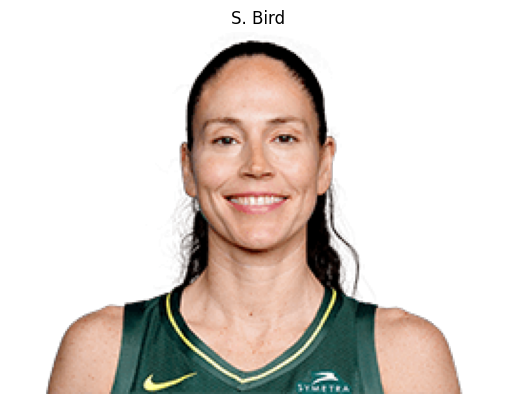

In [ ]:
# Quick isolated test
players = parse_lineup(top5.iloc[0])
for name, pid in players:
    img_arr, is_sil = get_headshot(pid, name)
    print(f"{name}: silhouette={is_sil}, arr={img_arr is not None}")
    if img_arr is not None:
        fig_test, ax_test = plt.subplots()
        ax_test.imshow(img_arr)
        ax_test.axis('off')
        plt.title(name)
        plt.show()
        break

In [ ]:
# Get player IDs from your top lineup
players = parse_lineup(top5.iloc[0])
print("Players and IDs:")
for name, pid in players:
    print(f"  {name}: {pid}")
    url = f"https://cdn.wnba.com/headshots/wnba/latest/260x190/{pid}.png"
    response = requests.get(url, headers=headers, timeout=5)
    print(f"  Status: {response.status_code}, Size: {len(response.content)} bytes")

Players and IDs:
  S. Bird: 100720
  Status: 200, Size: 18305 bytes
  A. Clark: 202252
  Status: 200, Size: 14500 bytes
  N. Howard: 203827
  Status: 200, Size: 16742 bytes
  J. Loyd: 204319
  Status: 200, Size: 13115 bytes
  B. Stewart: 1627668
  Status: 200, Size: 16096 bytes


S. Bird: silhouette=False, arr=True


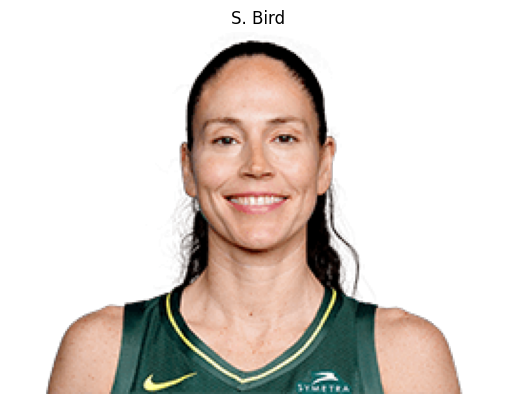

In [ ]:
# Quick isolated test
players = parse_lineup(top5.iloc[0])
for name, pid in players:
    img_arr, is_sil = get_headshot(pid, name)
    print(f"{name}: silhouette={is_sil}, arr={img_arr is not None}")
    if img_arr is not None:
        fig_test, ax_test = plt.subplots()
        ax_test.imshow(img_arr)
        ax_test.axis('off')
        plt.title(name)
        plt.show()
        break

In [33]:
# storm logo
logo_urls = [
    "https://cdn.wnba.com/logos/wnba/1611661328/primary/L/logo.svg",
    "https://cdn.wnba.com/logos/wnba/1611661328/primary/L/logo.png",
    "https://www.wnba.com/assets/img/teams/logos/SEA.svg"
]

for url in logo_urls:
    response = requests.get(url, headers=headers)
    print(f"{url}")
    print(f"  Status: {response.status_code}, Size: {len(response.content)} bytes\n")

https://cdn.wnba.com/logos/wnba/1611661328/primary/L/logo.svg
  Status: 200, Size: 2708 bytes

https://cdn.wnba.com/logos/wnba/1611661328/primary/L/logo.png
  Status: 200, Size: 43731 bytes

https://www.wnba.com/assets/img/teams/logos/SEA.svg
  Status: 403, Size: 243 bytes



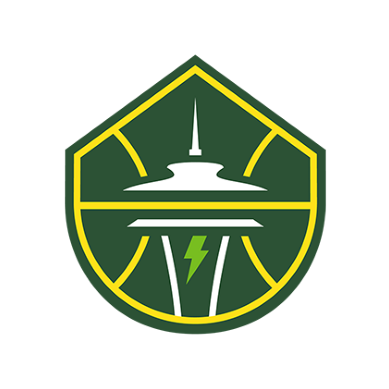

Logo size: (400, 400)


In [34]:
logo_url = "https://cdn.wnba.com/logos/wnba/1611661328/primary/L/logo.png"
response = requests.get(logo_url, headers=headers)
logo_img = PILImage.open(BytesIO(response.content)).convert('RGBA')
logo_arr = np.array(logo_img)

# Test display
fig_test, ax_test = plt.subplots()
ax_test.imshow(logo_arr)
ax_test.axis('off')
plt.show()
print(f"Logo size: {logo_img.size}")

In [ ]:
# we are going to need to manually download some headshots
# find the ones we need
os.makedirs(HEADSHOT_DIR, exist_ok=True)

print("Players needing manual headshots:")
for _, lineup_row in top5.iterrows():
    players = parse_lineup(lineup_row)
    for name, pid in players:
        local_path = os.path.join(HEADSHOT_DIR, f'{pid}.png')
        if not os.path.exists(local_path):
            img_arr, is_sil = get_headshot(pid, name)
            if is_sil:
                print(f"  {name} (ID: {pid})")

Players needing manual headshots:
  S. Cash (ID: 100721)
  S. Brondello (ID: 100247)
  K. Vodichkova (ID: 100544)
  A. Lassiter (ID: 100642)
  J. Burse (ID: 100660)
  I. Castro Marques (ID: 100796)
  S. Cash (ID: 100721)


In [127]:
# QC
top5_check = (adv_df[adv_df['POSS'] >= 200]
              .nlargest(5, 'NET_RATING')
              [['SEASON', 'GROUP_NAME', 'NET_RATING', 'OFF_RATING', 'DEF_RATING', 'POSS']]
              .reset_index(drop=True))

top5_check.index += 1
print(top5_check.to_string())

   SEASON                                                 GROUP_NAME  NET_RATING  OFF_RATING  DEF_RATING  POSS
1    2020      S. Bird - A. Clark - N. Howard - J. Loyd - B. Stewart        23.4       111.9        88.4   345
2    2022  S. Bird - T. Charles - J. Loyd - B. Stewart - G. Williams        20.9       114.7        93.9   455
3    2018      S. Bird - A. Clark - N. Howard - J. Loyd - B. Stewart        20.6       117.6        97.1  1094
4    2021    S. Bird - S. Talbot - J. Loyd - B. Stewart - M. Russell        19.3       106.5        87.1   278
5    2010     L. Jackson - S. Bird - S. Cash - T. Wright - C. Little        17.0       106.6        89.6   834
